In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from time import time
from typing import Tuple
from scipy.optimize import curve_fit
import pickle
from sim import line_sim, cyclic_sim
from numba import njit, prange
from Z_utils import *

In [2]:
q=1

L = 300
T = 100
kon = 1
koff = 1
kstep = 100
kq = 100
initial_percentage = 50


In [3]:
data, times, res, dt = cyclic_sim(L, T, 0.0001, 0.0001, kstep, 1000, 10, 90)

90


(999, 300)

In [5]:
@njit
def calc_current(res, dt):
    DT = np.cumsum(dt)
    index = int(len(DT)/100)
    start = DT[-index]
    end = DT[-1] 
    a=np.where(res[-index:]==2)[0]
    return len(a)/(end-start)

In [8]:
q=5


# Q = np.linspace(1.1,8,Nq)
Initials = [10,20,30,40,50,60,70,80,90]

lamda = np.zeros(len(Initials))
lamda_var = np.zeros_like(lamda)
num_kins = np.zeros_like(lamda)
current = np.zeros_like(lamda)


for j in range(len(Initials)):
    data, times, res, dt = cyclic_sim(L, T, 0.0001, 0.0001, kstep, 1000, 10, Initials[j])
    num_kins[j] = np.mean(np.sum(data[:, :], axis=1))
    lamda[j], lamda_var[j] = fit_cdf(res, dt, get_stepping_data)
    current[j] = calc_current(res,dt)
semi_current = num_kins*lamda
# M = np.max(semi_current)
# idx = np.where(semi_current==M)[0][0]
# semi_current = num_kins*lamda

10
20
30
40
50
60
70
80
90


In [13]:
data, times, res, dt = cyclic_sim(L,100*T, 0.0001, 0.0001, 0.001, 1.0, 90)

In [14]:
np.mean(data[10])

0.54

In [15]:
len(dt)

1927

In [22]:
num_kins

array([nan, nan, nan, nan, nan, nan, nan, nan, nan])

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


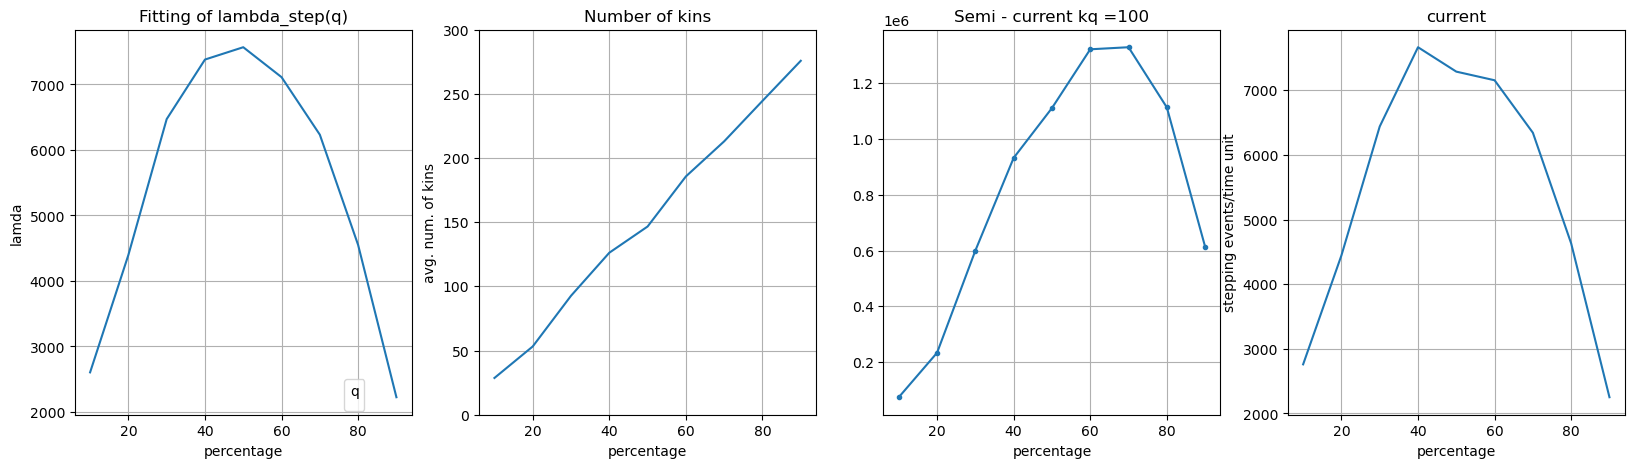

In [9]:
fig, (ax1, ax2, ax3,ax4) = plt.subplots(1,4, figsize=(20,5))

ax1.plot(Initials, lamda)
ax1.set(xlabel = "percentage", ylabel = "lamda", title = "Fitting of lambda_step(q)")
ax1.grid()
ax1.legend(loc = (0.8,0.01),title="q")

ax2.plot(Initials, num_kins)
ax2.set(xlabel = "percentage", ylabel = "avg. num. of kins", title = "Number of kins", ylim = [0,300])
ax2.grid()

semi_current = num_kins*lamda

ax3.plot(Initials, semi_current, marker=".")
ax3.set(xlabel = "percentage", ylabel = "", title = "Semi - current kq =100")
ax3.grid()

ax4.plot(Initials, current)
ax4.set(xlabel = "percentage", ylabel = "stepping events/time unit", title = "current")
ax4.grid()

In [10]:
fig.savefig("confirmation.png", dpi =300)

In [11]:
# Initials = [10,20,30,40,50,60,70,80,90]
KON = np.linspace(0.1,10,20)
lamda = np.zeros(len(KON))
lamda_var = np.zeros_like(lamda)
num_kins = np.zeros_like(lamda)
current = np.zeros_like(lamda)


for j in range(len(KON)):
    data, times, res, dt = cyclic_sim(L, T, KON[j], 1.0, kstep, 0.0001, 1, initial_density=0)
    num_kins[j] = np.mean(np.sum(data[:, :], axis=1))
    lamda[j], lamda_var[j] = fit_cdf(res, dt, get_stepping_data)
    current[j] = calc_current(res,dt)
semi_current = num_kins*lamda

0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0
0


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


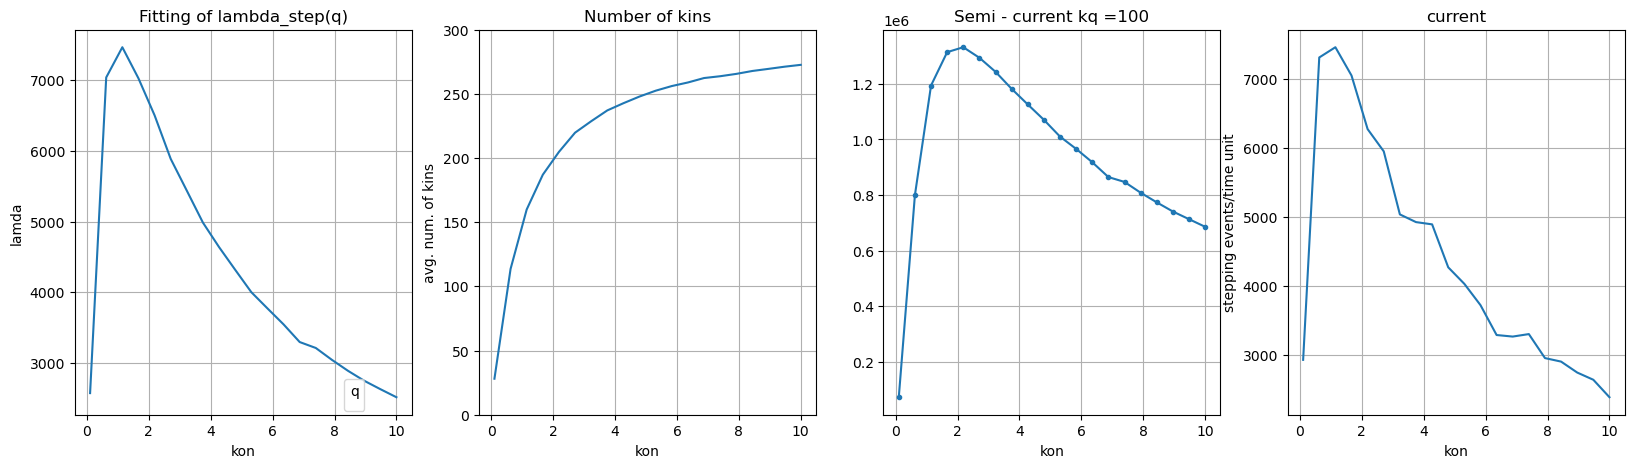

In [14]:
fig, (ax1, ax2, ax3,ax4) = plt.subplots(1,4, figsize=(20,5))

ax1.plot(KON, lamda)
ax1.set(xlabel = "kon", ylabel = "lamda", title = "Fitting of lambda_step(q)")
ax1.grid()
ax1.legend(loc = (0.8,0.01),title="q")

ax2.plot(KON, num_kins)
ax2.set(xlabel = "kon", ylabel = "avg. num. of kins", title = "Number of kins", ylim = [0,300])
ax2.grid()

semi_current = num_kins*lamda

ax3.plot(KON, semi_current, marker=".")
ax3.set(xlabel = "kon", ylabel = "", title = "Semi - current kq =100")
ax3.grid()

ax4.plot(KON, current)
ax4.set(xlabel = "kon", ylabel = "stepping events/time unit", title = "current")
ax4.grid()

In [15]:
fig.savefig("cycle.png", dpi=300)

In [20]:
num_kins

array([nan, nan, nan, nan, nan, nan, nan, nan, nan])